In [1]:
import requests
import time
import numpy as np

# DBPedia

In [5]:

endpoint = "http://dbpedia.org/sparql"
query = """
SELECT DISTINCT ?relatedEntity ?label
WHERE {
  dbr:Germany ?predicate ?relatedEntity.
  ?relatedEntity rdfs:label ?label.
  FILTER(LANG(?label) = 'en')
}
"""

params = {'format': 'json', 'query': query}
response = requests.get(endpoint, params=params)
data = response.json()

entities = [(result['relatedEntity']['value'], result['label']['value']) for result in data['results']['bindings']]

for uri, label in entities[:3]:
    print(f"Entity: {uri}, Label: {label}")

Entity: http://dbpedia.org/ontology/Person, Label: person
Entity: http://dbpedia.org/ontology/Place, Label: place
Entity: http://dbpedia.org/resource/Cabinet_of_Germany, Label: Cabinet of Germany


# Wikidata

In [30]:
def get_entity_info(wikidata_id):
    wikidata_api_url = f"https://www.wikidata.org/w/api.php?action=wbgetentities&format=json&ids={wikidata_id}"
    response = requests.get(wikidata_api_url)
    data = response.json()
    return data['entities'][wikidata_id]

# Example usage
wikidata_id = "Q42"  # Replace with the Wikidata ID
entity_info = get_entity_info(wikidata_id)
entity_value = entity_info['labels']['en']['value']
entity_value

'Douglas Adams'

In [26]:
def get_wikidata_id(entity_name):
    endpoint = "https://query.wikidata.org/sparql"
    query = f"""
    SELECT ?item
    WHERE {{
      ?item rdfs:label "{entity_name}"@en.
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "[AUTO_LANGUAGE],en". }}
    }}
    """
    headers = {
        "User-Agent": "YourApp/1.0 (your@email.com) Python-requests/2.26.0",
        "Accept": "application/json"
    }
    params = {'format': 'json', 'query': query}
    
    response = requests.get(endpoint, params=params, headers=headers)
    data = response.json()

    # Extract the Wikidata ID
    wikidata_id = data['results']['bindings'][0]['item']['value'].split('/')[-1]
    return wikidata_id

def get_entity_info(entity_name):
    wikidata_id = get_wikidata_id(entity_name)
    
    endpoint = "https://query.wikidata.org/sparql"
    query = f"""
    SELECT ?property ?propertyLabel ?object ?objectLabel
    WHERE {{
      wd:{wikidata_id} ?property ?object.
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "[AUTO_LANGUAGE],en". }}
    }}
    """
    headers = {
        "User-Agent": "YourApp/1.0 (your@email.com) Python-requests/2.26.0",
        "Accept": "application/json"
    }
    params = {'format': 'json', 'query': query}
    
    response = requests.get(endpoint, params=params, headers=headers)
    data = response.json()

    triples = [(result['property']['value'], result['propertyLabel']['value'], result['object']['value'], result['objectLabel']['value']) for result in data['results']['bindings']]
    return triples

# Example usage with a list of entities
entities = ["Roman Empire", "Ancient Rome"]
for entity in entities:
    triples = get_entity_info(entity)
    print(f"Triples for {entity}:")
    for triple in triples[:3]:
        print(triple)
    print("\n")



Triples for Roman Empire:
('http://www.wikidata.org/prop/direct/P41', 'http://www.wikidata.org/prop/direct/P41', 'http://commons.wikimedia.org/wiki/Special:FilePath/Vexilloid%20of%20the%20Roman%20Empire.svg', 'http://commons.wikimedia.org/wiki/Special:FilePath/Vexilloid%20of%20the%20Roman%20Empire.svg')
('http://www.wikidata.org/prop/direct/P47', 'http://www.wikidata.org/prop/direct/P47', 'http://www.wikidata.org/entity/Q1986139', 'Parthian Empire')
('http://www.wikidata.org/prop/direct/P112', 'http://www.wikidata.org/prop/direct/P112', 'http://www.wikidata.org/entity/Q1405', 'Augustus')


Triples for Ancient Rome:
('http://www.w3.org/2000/01/rdf-schema#label', 'http://www.w3.org/2000/01/rdf-schema#label', 'Rom antik', 'Rom antik')
('http://www.w3.org/2000/01/rdf-schema#label', 'http://www.w3.org/2000/01/rdf-schema#label', 'An t-Seann Ròimh', 'An t-Seann Ròimh')
('http://www.w3.org/2000/01/rdf-schema#label', 'http://www.w3.org/2000/01/rdf-schema#label', 'Roma Antiga', 'Roma Antiga')




# TREx Dataset

In [25]:
import os
import json

In [24]:
input_file_path = "../data/data_lama/TREx/P108.jsonl"
output_file_path = "../data/dataset/TREx/TREx_relations_P108.jsonl"
predicate_description_file_path = "../data/data_lama/relations.jsonl"

predicate_dict = {}
with open(predicate_description_file_path, 'r') as predicate_file:
    for line in predicate_file:
        predicate_entry = json.loads(line)
        predicate_dict[predicate_entry['relation']] = predicate_entry['label']

def extract_metadata(entry):
    return{
        'sub_label': entry['sub_label'],
        'sub_uri': entry['sub_uri'],
        'obj_label': entry['obj_label'],
        'obj_uri': entry['obj_uri'],
        'predicate_label': predicate_dict.get(entry['predicate_id'], entry['predicate_id']),
        'predicate_id': entry['predicate_id'],
    }

with open(input_file_path, 'r') as input_file, open(output_file_path, 'w') as output_file:
    for line in input_file:
        entry = json.loads(line)
        metadata = extract_metadata(entry)
        output_file.write(json.dumps(metadata) + '\n')

print("Metadata extraction completed.")

Metadata extraction completed.


In [28]:
# Concatenate all TREx files into one

directory_path = "../data/dataset/TREx"
output_file_path = "../data/dataset/TREx_all.jsonl"

jsonl_files = [f for f in os.listdir(directory_path) if f.endswith(".jsonl")]

with open(output_file_path, 'w') as output_file:
    for jsonl_file in jsonl_files:
        file_path = os.path.join(directory_path, jsonl_file)

        with open(file_path, 'r') as input_file:
            for line in input_file:
                output_file.write(line)

print("Concatenation completed. Output file:", output_file_path)

Concatenation completed. Output file: ../data/dataset/TREx_all.jsonl


## Trasform the triples into a graph

In [1]:
import json
import networkx as nx
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import SAGEConv

/Users/giacomomunda/Documents/Data Science/Python Projects/Advanced/kg_linear_transformation/kg-linear/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
jsonl_file_path = "../data/dataset/TREx/TREx_relations_P17.jsonl"


def create_graph(file_path: str):
    graph = nx.DiGraph()

    with open(file_path, 'r') as jsonl_file:
        for line in jsonl_file:
            triple = json.loads(line)

            subject = triple['sub_label']
            object_ = triple['obj_label']
            predicate = triple['predicate_label']

            graph.add_node(subject)
            graph.add_node(object_)
            graph.add_edge(subject, object_, label=predicate)

    return graph


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import MessagePassing, global_add_pool, GraphConv

In [6]:
class GNNModel(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super(GNNModel, self).__init__(aggr='add')
        self.conv1 = GraphConv(in_channels, out_channels)

    def forward(self, x, edge_index):
        return self.propagate(edge_index, x=x)
    
    def message(self,  x_i, x_j):
        return x_j
    
def graph_to_pyg_data(graph):
    edge_index = torch.tensor(list(graph.edges)).t().contiguous()
    x = torch.eye(graph.number_of_nodes()) # identity matrix
    data = Data(x=x, edge_index=edge_index)

    return data

model = GNNModel(in_channels=graph.number_of_nodes(), out_channels=graph.number_of_nodes())
data = graph_to_pyg_data(graph)
loader = DataLoader([data], batch_size=1, shuffle=False)

optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

for epoch in range (100):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out, torch.tensor([0]))
    loss.backward()
    optimizer.step()

    print(f"Epoch: {epoch}, Loss: {loss.item()}")

model.eval()
with torch.no_grad():
    embeddings = model(data.x, data.edge_index)

ValueError: too many dimensions 'str'

In [4]:
# Generate a sample graph
# graph = nx.DiGraph()
# graph.add_edges_from([("Eibenstock", "Germany"), ("Simcoe Composite School", "Canada")])


# Convert the NetworkX graph to PyTorch Geometric data
def graph_to_pyg_data(graph: nx.DiGraph):
    # Create a mapping from node labels to integer indices
    node_to_index = {node: index for index, node in enumerate(graph.nodes)}

    # Map edge labels to integer indices
    edge_index = torch.tensor([[node_to_index[edge[0]], node_to_index[edge[1]]] for edge in graph.edges]).t().contiguous()

    x = torch.randn(graph.number_of_nodes(), 100)  # Use random node features for illustration
    data = Data(x=x, edge_index=edge_index)
    return data

# Create the GraphSAGE model
class GraphSAGEModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GraphSAGEModel, self).__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        return x


JSONL_FILE_PATH  = "../data/dataset/TREx/TREx_all.jsonl"
graph = create_graph(JSONL_FILE_PATH)
# Convert the NetworkX graph to PyTorch Geometric data
data = graph_to_pyg_data(graph)
print(graph.number_of_nodes())
print(graph.number_of_edges())
print(graph.nodes)
print(graph.edges)

# Create the GraphSAGE model
model = GraphSAGEModel(in_channels=data.num_node_features, hidden_channels=300, out_channels=100)

# Initialize DataLoader
loader = DataLoader([data], batch_size=1, shuffle=False)

# Training loop for unsupervised learning
optimizer = optim.Adam(model.parameters(), lr=0.005)

for epoch in range(100):  # Adjust the number of epochs based on your task
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = torch.nn.functional.mse_loss(out, data.x)
    loss.backward()
    optimizer.step()
    print(f"Epoch: {epoch}, Loss: {loss.item()}")

# Extract node embeddings after training
model.eval()
with torch.no_grad():
    embeddings = model(data.x, data.edge_index)



8126
7905
['Eibenstock', 'Germany', 'Simcoe Composite School', 'Canada', 'Vrienden van het Platteland', 'Netherlands', 'Cunter', 'Switzerland', 'Glencree', 'Ireland', "L'Escala", 'Spain', 'Wismar', 'Namba Station', 'Japan', '2010 Belgian federal election', 'Belgium', 'CFMJ', 'Amos Anderson Art Museum', 'Finland', 'Zelenchukskaya', 'Russia', "Santo Stefano d'Aveto", 'Italy', 'SooToday.com', 'Sena Medal', 'India', 'Lake Caliraya', 'Philippines', 'Didymoteicho', 'Greece', '2004 Indian Ocean earthquake', 'Indonesia', 'Fawkner', 'Australia', 'Abu Ghosh', 'Israel', 'Hagenow', 'Mexican Stock Exchange', 'Mexico', 'By-elections to the 41st Canadian Parliament', 'Maison du Peuple', 'Wakefield Park', 'Sands of Beirut', 'Lebanon', 'Baturyn', 'Ukraine', 'Suwayq', 'Oman', 'CD Eldense', 'Taksim Military Barracks', 'Turkey', 'Mbale District', 'Uganda', 'Yokohama International School', 'Reiherstieg Schiffswerfte & Maschinenfabrik', 'HSBC Bank Malta', 'Malta', 'Siquijor', 'Ufa', 'Augustinergasse', 'Demo

/Users/giacomomunda/Documents/Data Science/Python Projects/Advanced/kg_linear_transformation/kg-linear/lib/python3.10/site-packages/torch_geometric/deprecation.py:22: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch: 4, Loss: 0.7108615636825562
Epoch: 5, Loss: 0.6404497623443604
Epoch: 6, Loss: 0.5693537592887878
Epoch: 7, Loss: 0.5042561888694763
Epoch: 8, Loss: 0.44762498140335083
Epoch: 9, Loss: 0.39578717947006226
Epoch: 10, Loss: 0.3478562533855438
Epoch: 11, Loss: 0.3069988191127777
Epoch: 12, Loss: 0.2729669511318207
Epoch: 13, Loss: 0.243562251329422
Epoch: 14, Loss: 0.21887964010238647
Epoch: 15, Loss: 0.19928939640522003
Epoch: 16, Loss: 0.18404263257980347
Epoch: 17, Loss: 0.17101936042308807
Epoch: 18, Loss: 0.1609823852777481
Epoch: 19, Loss: 0.1532946079969406
Epoch: 20, Loss: 0.14648845791816711
Epoch: 21, Loss: 0.14073842763900757
Epoch: 22, Loss: 0.1367616057395935
Epoch: 23, Loss: 0.13212187588214874
Epoch: 24, Loss: 0.12869474291801453
Epoch: 25, Loss: 0.1254158765077591
Epoch: 26, Loss: 0.12165354937314987
Epoch: 27, Loss: 0.118827223777771
Epoch: 28, Loss: 0.11571633815765381
Epoch: 29, Loss: 0.11270759999752045
Epoch: 30, Loss: 0.10997506976127625
Epoch: 31, Loss: 0.107

In [56]:
embeddings.shape

torch.Size([8126, 100])

In [38]:
import torch.nn.functional as F
#from sklearn.metrics.pairwise import cosine_similarity

In [57]:
# # Function to compute cosine similarity between two vectors
def cosine_similarity(x1, x2, dim=0, eps=1e-8):
    dot_product = torch.sum(x1 * x2, dim)
    norm_x1 = torch.norm(x1, 2, dim)
    norm_x2 = torch.norm(x2, 2, dim)
    similarity = dot_product / (norm_x1 * norm_x2 + eps)
    return similarity

# Compute similarity scores between pairs of embeddings
def compute_similarity(embeddings):
    similarity_scores = []
    num_embeddings = embeddings.size(0)

    for i in range(num_embeddings - 1):
        for j in range(i + 1, num_embeddings):
            similarity = cosine_similarity(embeddings[i], embeddings[j])
            similarity_scores.append(similarity.item())

    return similarity_scores

# Convert embeddings to a NumPy array for similarity computation
embeddings_numpy = embeddings.numpy()

# Compute similarity scores
similarity_scores = compute_similarity(torch.Tensor(embeddings_numpy[:20]))

In [58]:
similarity_scores

[-0.0006753587513230741,
 0.07281772792339325,
 0.043776825070381165,
 0.013829835690557957,
 -0.1593811959028244,
 -0.028279686346650124,
 0.1539352983236313,
 -0.033401161432266235,
 0.04103205353021622,
 0.00889517180621624,
 -0.023433959111571312,
 0.011068414896726608,
 -0.1180110052227974,
 0.0665195882320404,
 0.09123433381319046,
 0.11219298094511032,
 0.007411067374050617,
 0.0034701870754361153,
 -0.018982278183102608,
 -0.0006264836410991848,
 0.2155422419309616,
 0.06135424226522446,
 0.020100833848118782,
 0.10936499387025833,
 -0.057590268552303314,
 -0.06161848083138466,
 0.15299689769744873,
 -0.005506462883204222,
 0.18995487689971924,
 -0.10850480943918228,
 0.010750764049589634,
 0.09804514795541763,
 -0.04325253888964653,
 0.0442352220416069,
 0.011619498953223228,
 0.03700818121433258,
 0.09248620271682739,
 0.10472162812948227,
 -0.11560427397489548,
 -0.022713158279657364,
 -0.058863088488578796,
 -0.04734110087156296,
 0.07264155149459839,
 0.10443630814552307,


### Plotting the embeddings

In [7]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

IndexError: index 20 is out of bounds for axis 0 with size 20

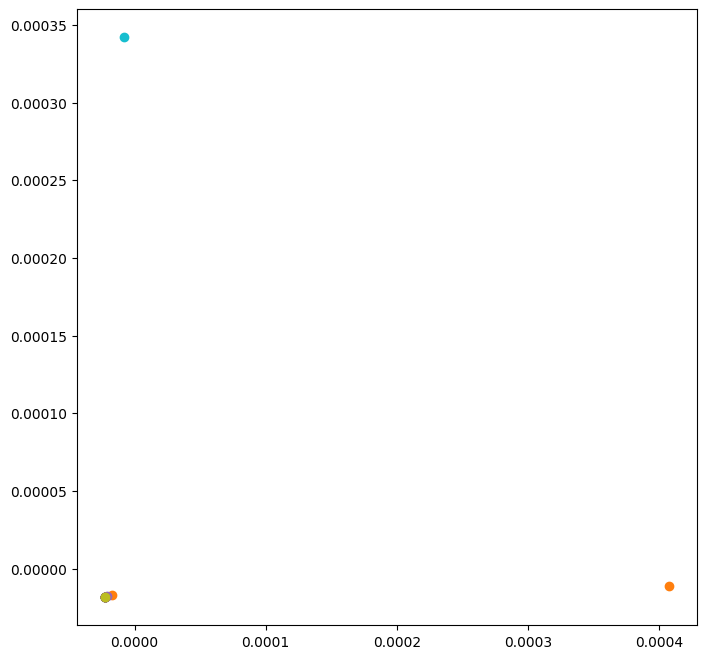

In [35]:
# Get the embeddings as a NumPy array
embeddings_numpy = embeddings.numpy()

# Perform PCA for dimensionality reduction to 2D
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_numpy)

# Plot the embeddings
plt.figure(figsize=(8, 8))
for i, label in enumerate(graph.nodes):
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], label=label)

for i, label in enumerate(graph.nodes):
    plt.annotate(label, (embeddings_2d[i, 0], embeddings_2d[i, 1]))

plt.title("Node Embeddings Visualization")
plt.legend()
plt.show()


In [36]:
import torch
import plotly.express as px
from sklearn.decomposition import PCA

# Get the embeddings as a NumPy array
embeddings_numpy = embeddings.numpy()

# Perform PCA for dimensionality reduction to 2D
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_numpy)

# Create a DataFrame for Plotly
import pandas as pd
df = pd.DataFrame(embeddings_2d, columns=['X', 'Y'])
df['Label'] = list(graph.nodes)

# Create an interactive scatter plot using Plotly Express
fig = px.scatter(df, x='X', y='Y', text='Label', title='Node Embeddings Visualization', labels={'text': 'Node'})
fig.update_traces(textposition='top center')

# Show the interactive plot
fig.show()

# WEMBEDDER

In [6]:
most_similar = requests.get('https://wembedder.toolforge.org/api/most-similar/Q18618629')
most_similar.json()

{'model_metadata': {'filename': 'wikidata-20170613-truthy-BETA-cbow-size=100-window=1-min_count=20-iter=25'},
 'most_similar': [{'item': 'Q20895241', 'similarity': 0.8968033194541931},
  {'item': 'Q1223539', 'similarity': 0.8891161680221558},
  {'item': 'Q546092', 'similarity': 0.8887224793434143},
  {'item': 'Q5111731', 'similarity': 0.8875998258590698},
  {'item': 'Q5534494', 'similarity': 0.8875308632850647},
  {'item': 'Q2908140', 'similarity': 0.885554313659668},
  {'item': 'Q4714332', 'similarity': 0.8830370903015137},
  {'item': 'Q602278', 'similarity': 0.8823263049125671},
  {'item': 'Q1672008', 'similarity': 0.8816208243370056},
  {'item': 'Q692804', 'similarity': 0.8815251588821411}],
 'size_of_vocabulary': 609471}

In [29]:
kg_embedding1 = requests.get('https://wembedder.toolforge.org/api/vector/Q57881')
kg_embedding2 = requests.get('https://wembedder.toolforge.org/api/vector/Q183')
response1 = kg_embedding1.json()
response2 = kg_embedding2.json()

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

In [30]:
vector_eibenstock = np.array(response1['vector'])
vector_germany = np.array(response2['vector'])

In [32]:
print(cosine_similarity(vector_eibenstock.reshape(1, -1), vector_germany.reshape(1, -1)))

[[0.28527222]]


In [33]:
similarity = requests.get('https://wembedder.toolforge.org/api/similarity/Q57881/Q183')
similarity.json()

{'model_metadata': {'filename': 'wikidata-20170613-truthy-BETA-cbow-size=100-window=1-min_count=20-iter=25'},
 'similarity': 0.2852722108364105}